In [1]:
from FLStep import *
from iLQGStep import *
from DLQGStep import *
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np



d:\thyriona\Desktop\Codes\My_research\WP1\CurrentParts\TorqueStep\iLQGStep.py:435: ComplexWarning: Casting complex values to real discards the imaginary part
  S[k] = Q[k] + A[k].T @ S[k + 1] @ A[k] - G.T @ Hinv @ G
d:\thyriona\Desktop\Codes\My_research\WP1\CurrentParts\TorqueStep\iLQGStep.py:436: ComplexWarning: Casting complex values to real discards the imaginary part
  sbold[k] = qbold[k] + A[k].T @ sbold[k + 1] - G.T @ Hinv @ gbold
d:\thyriona\Desktop\Codes\My_research\WP1\CurrentParts\TorqueStep\iLQGStep.py:437: ComplexWarning: Casting complex values to real discards the imaginary part
  s[k] = q[k] + s[k + 1] + 0.5 * temp3 - 0.5 * gbold.T @ Hinv @ gbold
d:\thyriona\Desktop\Codes\My_research\WP1\CurrentParts\TorqueStep\iLQGStep.py:439: ComplexWarning: Casting complex values to real discards the imaginary part
  l[k] = -Hinv @ gbold
d:\thyriona\Desktop\Codes\My_research\WP1\CurrentParts\TorqueStep\iLQGStep.py:440: ComplexWarning: Casting complex values to real discards the imagina

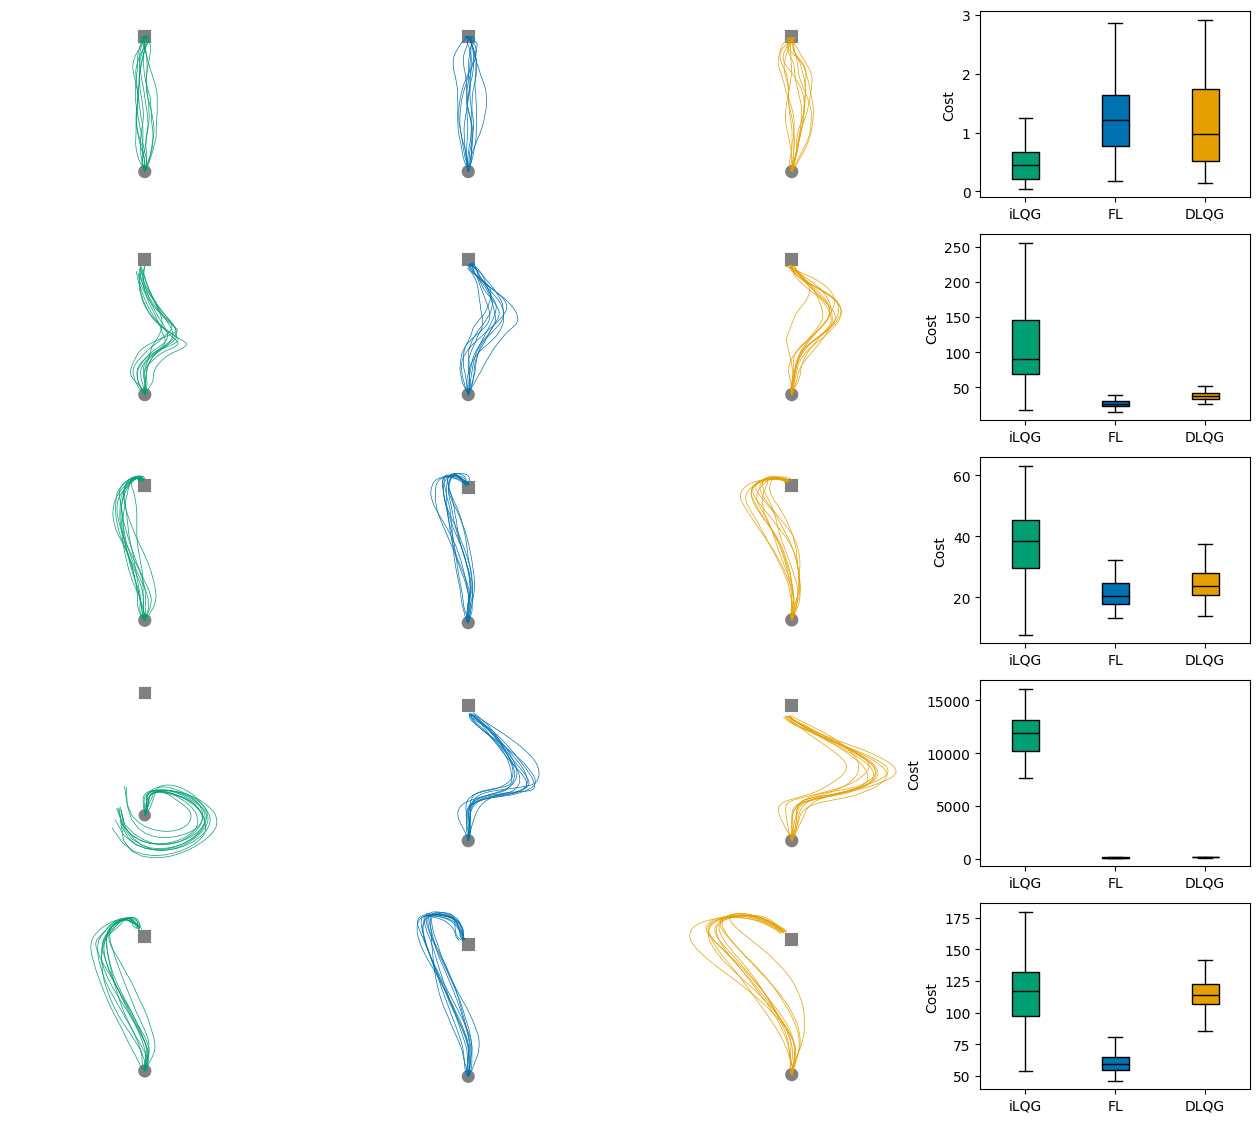

d:\thyriona\Desktop\Codes\My_research\WP1\CurrentParts\TorqueStep\iLQGStep.py:435: ComplexWarning: Casting complex values to real discards the imaginary part
  S[k] = Q[k] + A[k].T @ S[k + 1] @ A[k] - G.T @ Hinv @ G
d:\thyriona\Desktop\Codes\My_research\WP1\CurrentParts\TorqueStep\iLQGStep.py:436: ComplexWarning: Casting complex values to real discards the imaginary part
  sbold[k] = qbold[k] + A[k].T @ sbold[k + 1] - G.T @ Hinv @ gbold
d:\thyriona\Desktop\Codes\My_research\WP1\CurrentParts\TorqueStep\iLQGStep.py:437: ComplexWarning: Casting complex values to real discards the imaginary part
  s[k] = q[k] + s[k + 1] + 0.5 * temp3 - 0.5 * gbold.T @ Hinv @ gbold
d:\thyriona\Desktop\Codes\My_research\WP1\CurrentParts\TorqueStep\iLQGStep.py:439: ComplexWarning: Casting complex values to real discards the imaginary part
  l[k] = -Hinv @ gbold
d:\thyriona\Desktop\Codes\My_research\WP1\CurrentParts\TorqueStep\iLQGStep.py:440: ComplexWarning: Casting complex values to real discards the imagina

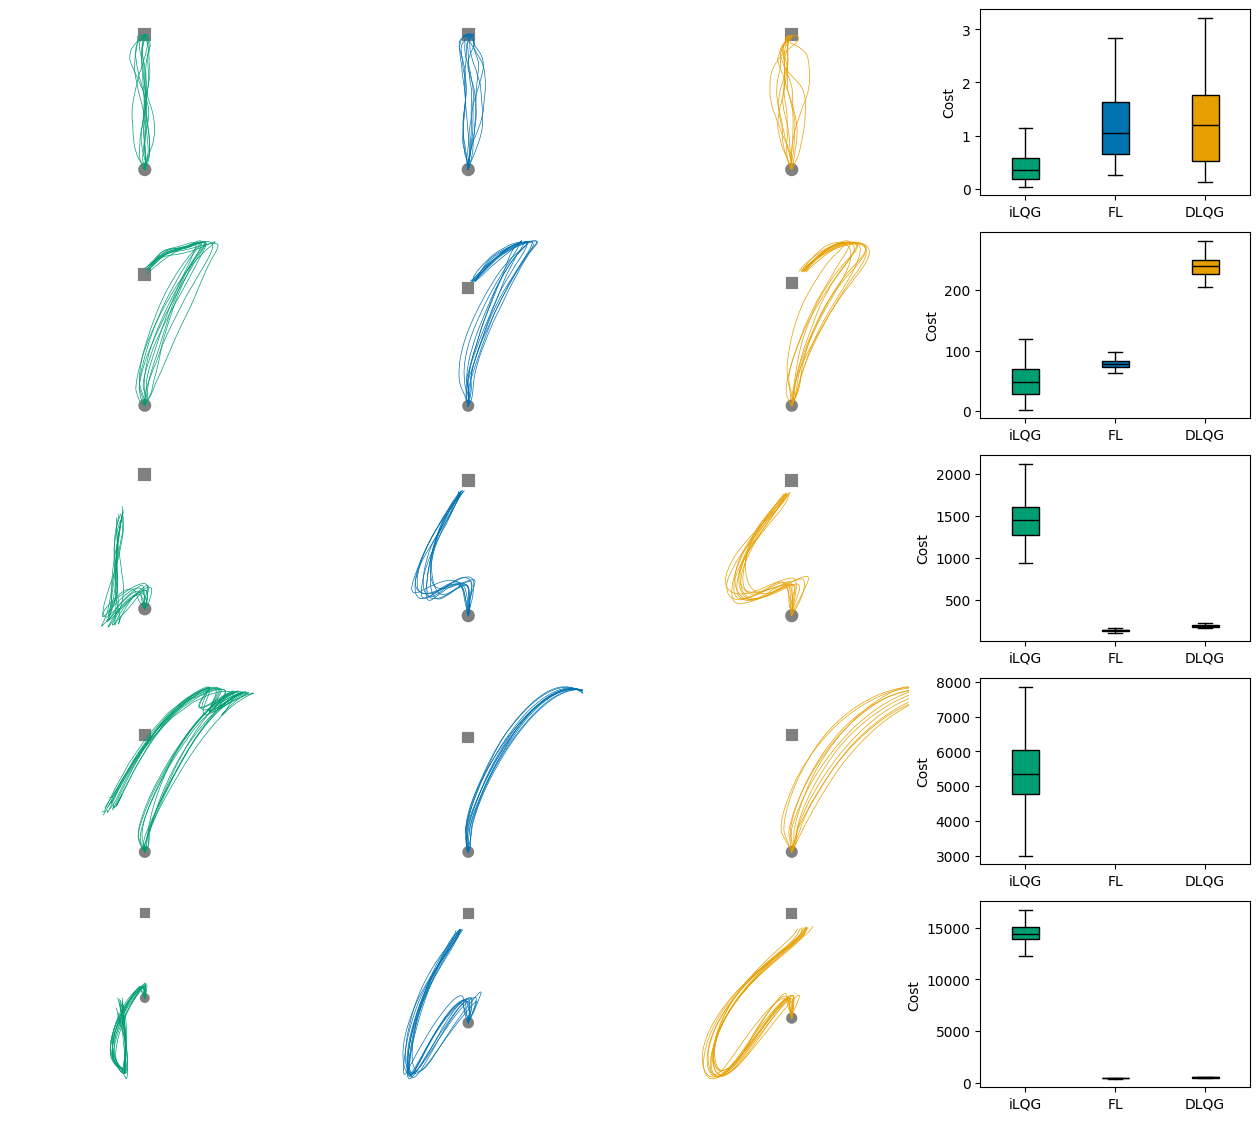

In [24]:
MV = 5e-4
WP = 20000
WV = 1
WR = .5
WRFL = 1e-8

NUM_SIM = 100

MovementTime = .8
NumIteration = 80
Time = np.linspace(0,MovementTime,NumIteration)*1000
Cost_value = np.zeros((NUM_SIM,3))
X0= [70,70]
XN=[-10,100]

def Cost_function(x,u,w1 = WP,w2 = WV,r = WR,tg = [0,0] ):
    target1,target2 = compute_angles_from_cartesian(tg[0],tg[1])
    thetas,thetae,omegas,omegae = x[-1,:4]
    
    return w1*(thetas-target1)**2 + w1*(thetae-target2)**2 + w2*(omegas**2+omegae**2)+ np.sum(u*u) * r

def delete_axis(ax, sides=["left", "right", "bottom", "top"]):
    for side in sides:
        ax.spines[side].set_visible(False)

NOISE = True

st = [0,40]
tg = [0,55]
colors = ["#009E73","#0072B2","#E69F00"]
tt = .2

for joint_pert in range(2):
    fig,ax = plt.subplots(5,4,figsize = (16,14))

    for idx,torque_amp in enumerate([0,-.5,.5,-1,1]):
        tv = [0,0]
        tv[joint_pert] = torque_amp
        ax1,ax2,ax3,ax4 = ax[idx]
        for n in range(NUM_SIM):
            xILQG,yILQG,zilqg,uILQG=simulate_ILQG(MovementTime,WP,WV,WR,tg,st,NumIteration,delay = 0.06,Noise=True,print_iterations=False,FF =  False,motornoise_variance=MV,torque_val=tv,torque_time = tt)
            xFL,yFL,xfl,uFL = simulate_FL(Duration=MovementTime,w1=WP,w2=WP,w3=WV,w4=WV,r=WRFL,Num_iter=NumIteration,starting_point=st,targets=tg,Delay = 0.06,Activate_Noise=True,FF = False,motornoise_variance=MV,torque_val=tv,torque_time = tt)
            xLQG,yLQG,uDLQG,z=DLQG_6Muscles(w1 = WP,w2 = WP,w3 = WV,w4 = WV, Duration=MovementTime,r1 = WR,Num_iter=NumIteration,starting_point=st,targets=tg,Delay = 0.06,Activate_Noise=True,FF = False,motornoise_variance=MV,torque_val=tv,torque_time = tt) 
            if n <= 10:
                ax1.plot(xILQG,yILQG, color=colors[0], linewidth=.5)
                ax2.plot(xFL,yFL, color=colors[1], linewidth=.5)
                ax3.plot(xLQG,yLQG, color=colors[2], linewidth=.5)
            Cost_value[n] = np.array([Cost_function(zilqg,uILQG,tg = tg),Cost_function(xfl,uFL,tg = tg),Cost_function(z.T,uDLQG,tg = tg)])

        for my_ax in [ax1,ax2,ax3]:
            circle = plt.Circle((st[0],st[1]), .5, edgecolor='grey',facecolor = "grey", linewidth=3)
            my_ax.add_patch(circle)
            square = plt.Rectangle((tg[0]-.5,tg[1]-.5), 1,1, edgecolor='grey',facecolor = "grey", linewidth=3)
            my_ax.add_patch(square)
            my_ax.set_aspect('equal')
            my_ax.set_xlim(-15, 15)
            my_ax.set_yticks([])
            my_ax.set_xticks([])
            delete_axis(my_ax)

        box = ax4.boxplot(Cost_value, patch_artist=True,
            medianprops=dict(color='black'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),showfliers=False)
        for patch, color in zip(box['boxes'], colors):
            patch.set_facecolor(color)
        ax4.set_xticklabels(['iLQG', 'FL', 'DLQG'])
        ax4.set_ylabel('Cost')
    plt.show()